# 🔐 MVP — Modelagem de Ameaças com IA
**Hackathon IADT — Fase 5 | 2026**

Pipeline completo: Dataset → Anotação → Treino YOLOv8 → OCR → Topologia → Motor STRIDE → Relatório

---
### Etapas do Notebook
| # | Etapa | Descrição |
|---|-------|-----------|
| 1 | Instalação de dependências | Instala todas as bibliotecas necessárias |
| 2 | Importações e configurações globais | Configura ambiente e paths |
| 3 | Coleta do Dataset Kaggle | Download do zip de imagens |
| 4 | Visualização e Carregamento de Amostras | Inspeção visual das primeiras 20 imagens |
| 5 | Anotação automática assistida | Gera anotações YOLO com heurísticas |
| 6 | Preparação dos splits | Divide em train/val/test |
| 7 | Configuração do YOLOv8 | Arquivo dataset.yaml e parâmetros |
| 8 | Treinamento do modelo | Fine-tune YOLOv8n nas classes arquiteturais |
| 9 | Avaliação e métricas | mAP, precisão, recall, matriz de confusão |
| 10 | Inferência em nova imagem | Detecta componentes no diagrama de entrada |
| 11 | Extração OCR | Lê rótulos textuais por região detectada |
| 12 | Construção de topologia | Monta grafo JSON da arquitetura |
| 13 | Motor STRIDE | Aplica regras de ameaça por componente/fluxo |
| 14 | Base de conhecimento | Knowledge base YAML de vulnerabilidades |
| 15 | Geração do relatório | Relatório Markdown estruturado |
| 16 | Visualização dos resultados | Exibe detecções e relatório no notebook |
| 17 | Interface Streamlit (export) | Código da demo UI |
| 18 | Entregáveis e instruções finais | GitHub, vídeo, documentação |


## Etapa 1 — Instalação de Dependências

In [3]:
# Etapa 1: Instalação de todas as dependências do pipeline
!pip install -q ultralytics paddleocr paddlepaddle opencv-python-headless \
    networkx matplotlib Pillow PyYAML jinja2 streamlit requests tqdm \
    pytesseract pyngrok

print('✅ Dependências instaladas')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4

In [4]:
import os
from google.colab import userdata

# Buscando credenciais dos Secrets com os nomes exatos fornecidos
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USER')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    os.environ['TK_NGROK'] = userdata.get('TK_NGROK')
    print("✅ Credenciais configuradas com sucesso via Secrets.")
except Exception as e:
    print(f"⚠ Erro ao acessar Secrets: {e}")


✅ Credenciais configuradas com sucesso via Secrets.


## Etapa 2 — Importações e Configurações Globais

In [5]:
# Etapa 2: Importações e configuração global de paths e taxonomia
import os, json, yaml, shutil, random, textwrap
from pathlib import Path
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from tqdm import tqdm
from google.colab import drive, files

# Montar Google Drive
drive.mount('/content/drive')

# Diretórios base
BASE_DIR   = Path('/content/drive/MyDrive/7iadt_hackathon_tm')
DATA_DIR   = BASE_DIR / 'data'
RAW_DIR    = DATA_DIR / 'raw'
ANN_DIR    = DATA_DIR / 'annotated'
SPLIT_DIR  = DATA_DIR / 'splits'
MODEL_DIR  = BASE_DIR / 'models'
OUTPUT_DIR = BASE_DIR / 'outputs'
EVAL_DIR   = DATA_DIR / 'eval_images'

RAW_IMAGES = RAW_DIR / 'images'
RAW_LABELS = RAW_DIR / 'labels'
CLEAN_DIR = DATA_DIR / 'cleaned'
BALANCED_DIR = DATA_DIR / 'balanced'

for d in [RAW_DIR, ANN_DIR, SPLIT_DIR/'images'/'train', SPLIT_DIR/'images'/'val',
          SPLIT_DIR/'images'/'test', SPLIT_DIR/'labels'/'train',
          SPLIT_DIR/'labels'/'val', SPLIT_DIR/'labels'/'test',
          MODEL_DIR, OUTPUT_DIR, RAW_IMAGES, RAW_LABELS, CLEAN_DIR, BALANCED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Taxonomia de classes arquiteturais
CLASSES = [
    'user_actor', 'web_client', 'api_gateway', 'application_service',
    'auth_service', 'database', 'message_queue', 'storage',
    'external_system', 'network_boundary'
]
NUM_CLASSES = len(CLASSES) if 'CLASSES' in globals() else 10
CLASS_ID = {c: i for i, c in enumerate(CLASSES)}
print(f'✅ Configuração OK | {len(CLASSES)} classes: {CLASSES}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Configuração OK | 10 classes: ['user_actor', 'web_client', 'api_gateway', 'application_service', 'auth_service', 'database', 'message_queue', 'storage', 'external_system', 'network_boundary']


## Etapa 3 — Coleta do Dataset (Kaggle)

### Download e extração das imagens de arquitetura de software diretamente do Kaggle via API.


In [6]:
import subprocess

def download_kaggle_dataset(dataset_slug, target_dir):
    """Download e extração de dataset do Kaggle"""
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    print(f"⬇ Baixando dataset: {dataset_slug}...")
    # Comando: kaggle datasets download -d user/dataset -p path --unzip
    result = subprocess.run(['kaggle', 'datasets', 'download', '-d', dataset_slug, '-p', str(target_dir), '--unzip'],
                            capture_output=True, text=True)

    if result.returncode == 0:
        print(f"✅ Dataset baixado e extraído em: {target_dir}")
    else:
        print(f"❌ Erro: {result.stderr}")


In [7]:
import zipfile
import shutil
import os
from pathlib import Path

# Configurações globais do dataset
DATASET_SLUG = 'carlosrian/software-architecture-dataset'
LIMITE_EXTRACAO = 49

print(f"✅ Configurações definidas: {DATASET_SLUG}")
# Configuração de extração seletiva
zip_name = "software-architecture-dataset.zip"
zip_path = RAW_DIR / zip_name

# 1. Download do Dataset DIRETAMENTE para o Google Drive
# O RAW_DIR já aponta para /content/drive/MyDrive/... conforme Etapa 2
if not zip_path.exists():
    print(f"⬇️ Baixando dataset diretamente para o Google Drive: {RAW_DIR}...")
    # Forçamos o download para o diretório de destino no Drive
    download_kaggle_dataset(DATASET_SLUG, RAW_DIR)
else:
    print(f"📦 O dataset {zip_name} já foi localizado no Google Drive. Download ignorado.")

# 2. Extração Seletiva para a raiz do RAW_DIR no Drive
if zip_path.exists():
    print(f"📂 Extraindo as primeiras {LIMITE_EXTRACAO} imagens para {RAW_DIR}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Filtra imagens ignorando a estrutura de pastas interna do zip
        image_entries = [f for f in zip_ref.namelist() if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        selected_entries = sorted(image_entries)[:LIMITE_EXTRACAO]

        for entry in selected_entries:
            target_name = Path(entry).name
            target_path = RAW_DIR / target_name

            # Extrai apenas se o arquivo ainda não existir descompactado
            if not target_path.exists():
                with zip_ref.open(entry) as source, open(target_path, "wb") as target:
                    shutil.copyfileobj(source, target)

    print(f"✅ Processamento concluído no Google Drive: {RAW_DIR}")
else:
    print("❌ Erro crítico: O arquivo zip não foi encontrado no diretório do Drive.")

✅ Configurações definidas: carlosrian/software-architecture-dataset
📦 O dataset software-architecture-dataset.zip já foi localizado no Google Drive. Download ignorado.
📂 Extraindo as primeiras 49 imagens para /content/drive/MyDrive/7iadt_hackathon_tm/data/raw...
✅ Processamento concluído no Google Drive: /content/drive/MyDrive/7iadt_hackathon_tm/data/raw


## Etapa 4 — Visualização e Carregamento de Amostras
Inspeção visual das primeiras 20 imagens carregadas para validar a integridade dos dados antes do processamento.

🖼️ Exibindo amostra de 20 imagens localizadas em /content/drive/MyDrive/7iadt_hackathon_tm/data/raw
🖼️ Carregando amostra de 20 imagens:



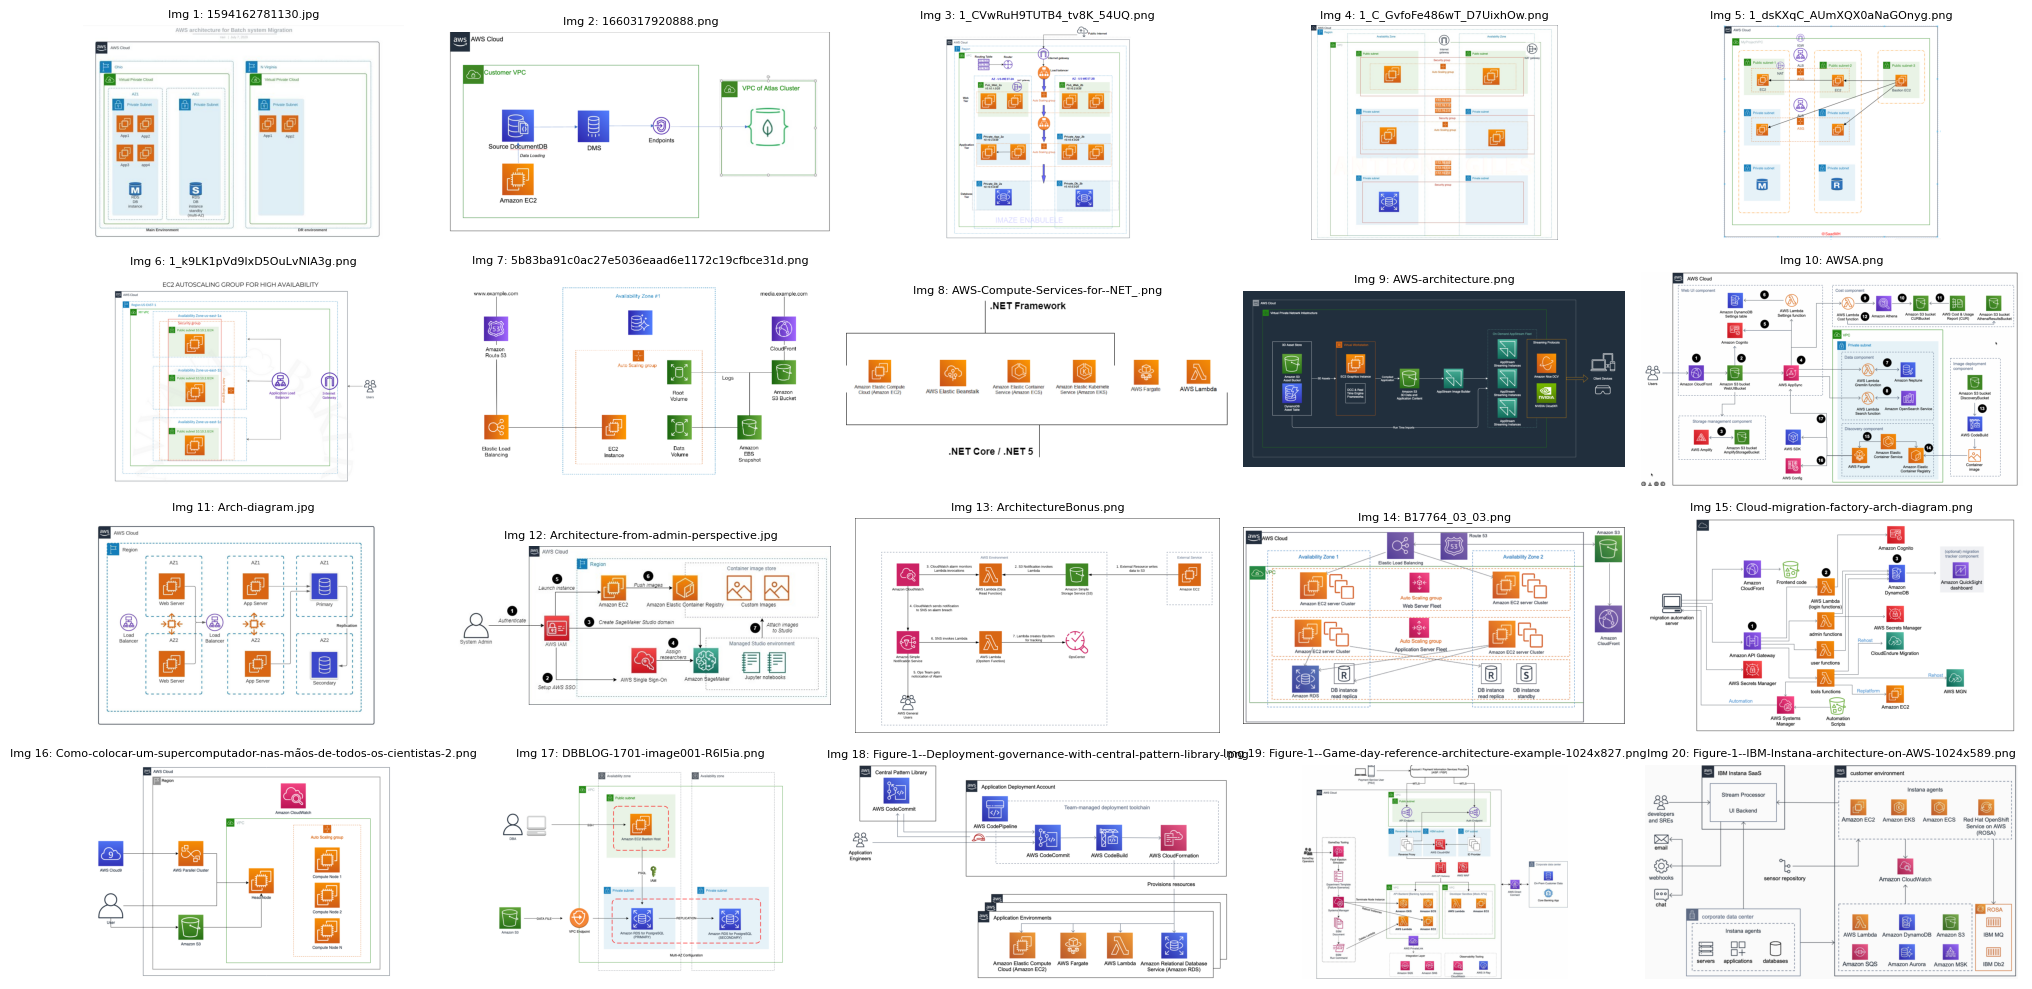

In [8]:
# Etapa 4: Visualização das imagens extraídas na raiz do RAW_DIR

import matplotlib.pyplot as plt
from PIL import Image

# 1. Listar arquivos de imagem no diretório
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
all_images = sorted([f for f in RAW_DIR.glob('**/*') if f.suffix.lower() in valid_extensions])

# 2. Selecionar apenas as 20 primeiras
subset_images = all_images[:20]

print(f"🖼️ Exibindo amostra de {len(subset_images)} imagens localizadas em {RAW_DIR}")
print(f"🖼️ Carregando amostra de {len(subset_images)} imagens:\n")

# 3. Carregar e exibir as imagens em um grid
plt.figure(figsize=(20, 10))
for i, img_path in enumerate(subset_images):
    img = Image.open(img_path)
    plt.subplot(4, 5, i + 1) # Grid de 4 linhas e 5 colunas
    plt.imshow(img)
    plt.title(f"Img {i+1}: {img_path.name}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Etapa 5 — Anotação Automática Assistida
Copia as anotações geradas para o formato YOLO e copia imagens brutas com anotações disponíveis.

In [9]:
import os
import random
import shutil
from pathlib import Path
from collections import Counter

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def limpar_rotulo_linha(line, num_classes=None):
    line = line.strip()
    if not line:
        return None
    parts = line.split()
    if len(parts) != 5:
        return None
    try:
        cls = int(float(parts[0]))
        vals = list(map(float, parts[1:]))
    except ValueError:
        return None
    x, y, w, h = vals
    if num_classes is not None and not (0 <= cls < num_classes):
        return None
    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
        return None
    if w * h < 0.0005:
        return None
    return f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}"

def limpar_dataset_yolo(images_dir, labels_dir, output_dir, num_classes=None, min_labels_por_imagem=1):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)
    output_dir = Path(output_dir)
    out_images = output_dir / 'images'
    out_labels = output_dir / 'labels'
    out_images.mkdir(parents=True, exist_ok=True)
    out_labels.mkdir(parents=True, exist_ok=True)
    stats = {
        'imagens_totais': 0,
        'imagens_validas': 0,
        'imagens_descartadas': 0,
        'labels_invalidos': 0,
        'labels_validos': 0,
        'classes': Counter()
    }
    image_files = [p for p in images_dir.rglob('*') if p.suffix.lower() in VALID_EXTS]
    for img_path in image_files:
        stats['imagens_totais'] += 1
        label_path = labels_dir / f'{img_path.stem}.txt'
        if not label_path.exists():
            stats['imagens_descartadas'] += 1
            continue
        cleaned = []
        for line in label_path.read_text(encoding='utf-8', errors='ignore').splitlines():
            row = limpar_rotulo_linha(line, num_classes=num_classes)
            if row is None:
                stats['labels_invalidos'] += 1
                continue
            cleaned.append(row)
            cls_id = int(row.split()[0])
            stats['classes'][cls_id] += 1
            stats['labels_validos'] += 1
        if len(cleaned) < min_labels_por_imagem:
            stats['imagens_descartadas'] += 1
            continue
        shutil.copy2(img_path, out_images / img_path.name)
        (out_labels / f'{img_path.stem}.txt').write_text('\n'.join(cleaned) + '\n', encoding='utf-8')
        stats['imagens_validas'] += 1
    return stats

def balancear_dataset_yolo(clean_images_dir, clean_labels_dir, balanced_dir, max_por_classe=None, seed=42):
    random.seed(seed)
    clean_images_dir = Path(clean_images_dir)
    clean_labels_dir = Path(clean_labels_dir)
    balanced_dir = Path(balanced_dir)
    out_images = balanced_dir / 'images'
    out_labels = balanced_dir / 'labels'
    out_images.mkdir(parents=True, exist_ok=True)
    out_labels.mkdir(parents=True, exist_ok=True)
    amostras_por_classe = {}
    for label_path in clean_labels_dir.glob('*.txt'):
        lines = [l.strip() for l in label_path.read_text(encoding='utf-8', errors='ignore').splitlines() if l.strip()]
        classes = sorted(set(int(l.split()[0]) for l in lines))
        for cls in classes:
            amostras_por_classe.setdefault(cls, []).append(label_path.stem)
    if not amostras_por_classe:
        return {'classes': {}, 'max_por_classe': 0, 'copiados': 0}
    if max_por_classe is None:
        max_por_classe = min(len(v) for v in amostras_por_classe.values())
    escolhidos = set()
    for cls, stems in amostras_por_classe.items():
        random.shuffle(stems)
        escolhidos.update(stems[:max_por_classe])
    copiados = 0
    for stem in escolhidos:
        label_src = clean_labels_dir / f'{stem}.txt'
        img_src = None
        for ext in VALID_EXTS:
            candidate = clean_images_dir / f'{stem}{ext}'
            if candidate.exists():
                img_src = candidate
                break
        if img_src is None:
            continue
        shutil.copy2(img_src, out_images / img_src.name)
        shutil.copy2(label_src, out_labels / label_src.name)
        copiados += 1
    return {
        'classes': {k: len(v) for k, v in amostras_por_classe.items()},
        'max_por_classe': max_por_classe,
        'copiados': copiados
    }



In [10]:
# Etapa 5B — Limpeza e balanceamento do dataset antes do treino
print('Iniciando limpeza do dataset YOLO...')
stats_limpeza = limpar_dataset_yolo(
    images_dir=RAW_IMAGES,
    labels_dir=RAW_LABELS,
    output_dir=CLEAN_DIR,
    num_classes=NUM_CLASSES,
    min_labels_por_imagem=1
)
print('Resumo da limpeza:', stats_limpeza)

print('Iniciando balanceamento do dataset...')
stats_balance = balancear_dataset_yolo(
    clean_images_dir=str(Path(CLEAN_DIR) / 'images'),
    clean_labels_dir=str(Path(CLEAN_DIR) / 'labels'),
    balanced_dir=BALANCED_DIR,
    max_por_classe=80,
    seed=42
)
print('Resumo do balanceamento:', stats_balance)
print('✅ Dataset preparado com menos ruído e menor desbalanceamento.')



Iniciando limpeza do dataset YOLO...
Resumo da limpeza: {'imagens_totais': 0, 'imagens_validas': 0, 'imagens_descartadas': 0, 'labels_invalidos': 0, 'labels_validos': 0, 'classes': Counter()}
Iniciando balanceamento do dataset...
Resumo do balanceamento: {'classes': {}, 'max_por_classe': 0, 'copiados': 0}
✅ Dataset preparado com menos ruído e menor desbalanceamento.


In [11]:
# Etapa 5C - Anotação Automática Assistida para Imagens Reais
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Mapeamento heurístico simples
def heuristic_class(w, h, W, H):
    try:
        ar = w / h if h > 0 else 1.0
        ra = (w * h) / (W * H) if (W * H) > 0 else 0
        if ar < 0.6 and ra < 0.03: return CLASSES.index('user_actor') if 'user_actor' in CLASSES else 0
        if 0.6 <= ar < 1.2 and ra < 0.04: return CLASSES.index('web_client') if 'web_client' in CLASSES else 1
        if ar >= 1.8 and ra < 0.06: return CLASSES.index('api_gateway') if 'api_gateway' in CLASSES else 2
        if 1.0 <= ar < 1.8 and 0.02 <= ra < 0.12: return CLASSES.index('application_service') if 'application_service' in CLASSES else 3
        if 0.8 <= ar < 1.3 and 0.01 <= ra < 0.05: return CLASSES.index('auth_service') if 'auth_service' in CLASSES else 4
        if ar >= 1.2 and ra >= 0.05: return CLASSES.index('database') if 'database' in CLASSES else 5
        if ar >= 2.5 and ra < 0.05: return CLASSES.index('message_queue') if 'message_queue' in CLASSES else 6
        if ar >= 1.5 and 0.03 <= ra < 0.10: return CLASSES.index('storage') if 'storage' in CLASSES else 7
        if ra >= 0.12: return CLASSES.index('external_system') if 'external_system' in CLASSES else 8
        return CLASSES.index('network_boundary') if 'network_boundary' in CLASSES else 9
    except NameError:
        return 0


print('Iniciando anotação assistida heurística para imagens reais em RAW_DIR...')
img_files = list(RAW_DIR.glob('*.png')) + list(RAW_DIR.glob('*.jpg'))
if not img_files:
    print('Nenhuma imagem encontrada em RAW_DIR. Verifique o download do Kaggle.')
else:
    for img_path in img_files:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        # Binarização e detecção de contornos para achar componentes arquiteturais
        _, thresh = cv2.threshold(img, 240, 255, cv2.THRESH_BINARY_INV)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        H, W = img.shape
        ann_file = ANN_DIR / f'{img_path.stem}.txt'
        with open(ann_file, 'w') as f:
            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)
                # Filtro para ignorar ruídos e pegar apenas formas principais
                if w > 40 and h > 40 and w < W*0.9 and h < H*0.9:
                    cx, cy = (x + w/2)/W, (y + h/2)/H
                    nw, nh = w/W, h/H
                    cls_id = heuristic_class(w, h, W, H)
                    f.write(f'{cls_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n')
    print(f'Anotações assistidas salvas no formato YOLO em {ANN_DIR}')


Iniciando anotação assistida heurística para imagens reais em RAW_DIR...
Anotações assistidas salvas no formato YOLO em /content/drive/MyDrive/7iadt_hackathon_tm/data/annotated


## Etapa 6 — Preparação dos Splits (Train / Val / Test)

In [12]:
# Etapa 6: Preparação dos Splits para Treinamento com Imagens Reais
import shutil
import random

images = list(RAW_DIR.glob('*.png')) + list(RAW_DIR.glob('*.jpg'))
if not images:
    print('Nenhuma imagem encontrada para o split.')
else:
    random.shuffle(images)
    split_idx = int(len(images) * 0.8)
    train_imgs, val_imgs = images[:split_idx], images[split_idx:]

    for split, imgs in [('train', train_imgs), ('val', val_imgs)]:
        img_dest = SPLIT_DIR / 'images' / split
        lbl_dest = SPLIT_DIR / 'labels' / split
        img_dest.mkdir(parents=True, exist_ok=True)
        lbl_dest.mkdir(parents=True, exist_ok=True)

        for img in imgs:
            shutil.copy(img, img_dest / img.name)
            txt_file = ANN_DIR / f'{img.stem}.txt'
            if txt_file.exists():
                shutil.copy(txt_file, lbl_dest / txt_file.name)
    print(f'Splits de imagens reais criados com sucesso nas pastas do YOLOv8!\nTreino: {len(train_imgs)} imagens | Validação: {len(val_imgs)} imagens')


Splits de imagens reais criados com sucesso nas pastas do YOLOv8!
Treino: 39 imagens | Validação: 10 imagens


## Etapa 7 — Configuração do YOLOv8 (dataset.yaml)

In [13]:
# Etapa 7: Gera o arquivo dataset.yaml exigido pelo YOLOv8
dataset_cfg = {
    'path': str(SPLIT_DIR),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': len(CLASSES),
    'names': CLASSES
}
yaml_path = SPLIT_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_cfg, f, default_flow_style=False, allow_unicode=True)

print('✅ dataset.yaml gerado em:', yaml_path)
print(yaml_path.read_text())

✅ dataset.yaml gerado em: /content/drive/MyDrive/7iadt_hackathon_tm/data/splits/dataset.yaml
names:
- user_actor
- web_client
- api_gateway
- application_service
- auth_service
- database
- message_queue
- storage
- external_system
- network_boundary
nc: 10
path: /content/drive/MyDrive/7iadt_hackathon_tm/data/splits
test: images/test
train: images/train
val: images/val



## Etapa 8 — Treinamento do Modelo YOLOv8
Fine-tune do YOLOv8n com pesos pré-treinados (transfer learning) nas 10 classes arquiteturais.

In [14]:
# Etapa 8: Treinamento YOLOv8n — ajuste os epochs conforme tempo disponível no Colab
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  # Modelo base leve para iteração rápida

results_train = model.train(
    data=str(yaml_path),
    epochs=80,          # Aumente para 100+ em produção
    imgsz=640,
    batch=16,
    name='hackathon_tm',
    project=str(MODEL_DIR),
    exist_ok=True,
    augment=True,
    mixup=0.1,
    patience=20,
    degrees=5.0,
    fliplr=0.5,
    mosaic=0.5,
    verbose=False
)
print('✅ Treinamento concluído')
print('📁 Pesos salvos em:', MODEL_DIR / 'hackathon_tm' / 'weights' / 'best.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/7iadt_hackathon_tm/data/splits/dataset.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist

## Etapa 9 — Avaliação e Métricas (mAP, Precisão, Recall)

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.7 ms, read: 133.3±138.2 MB/s, size: 1074.7 KB)
val: Scanning /content/drive/MyDrive/7iadt_hackathon_tm/data/splits/labels/val.cache... 189 images, 69 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 189/189 61.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.2s/it 14.4s
                   all        189       1505      0.536      0.615      0.509      0.439
Speed: 3.0ms preprocess, 11.1ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /content/runs/detect/val
📊 Métricas de Validação:
  mAP@50      : 0.5093
  mAP@50-95   : 0.4388
  Precisão    : 0.5357
  Recall      : 0.6150

🧪 DIAGNÓSTICO DE COLAPSO DE CLASSES:
  treino[user_actor] = 248
  treino[web_client] = 2914
  treino[api_gateway] = 388
 

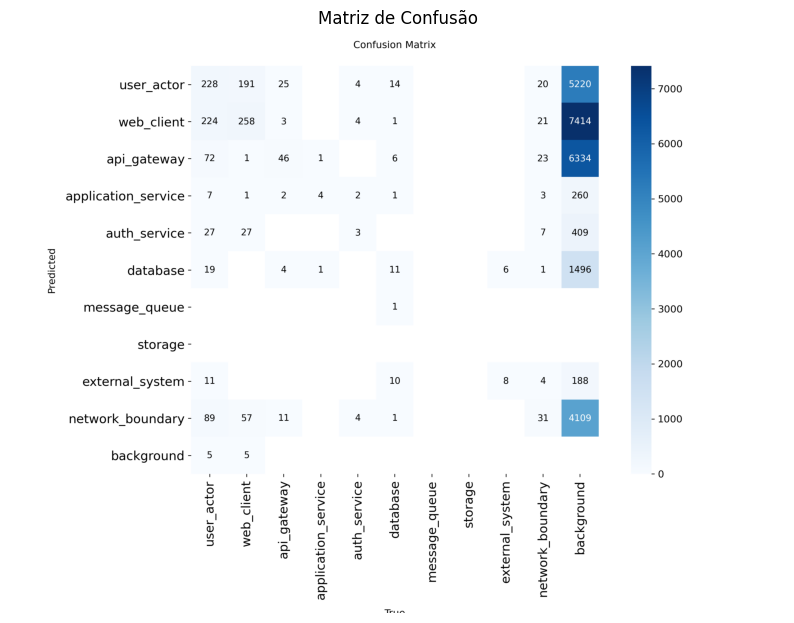

In [15]:
import matplotlib.pyplot as plt
import cv2

# Etapa 9: Avaliação no conjunto de validação
best_weights = MODEL_DIR / 'hackathon_tm' / 'weights' / 'best.pt'
model_eval = YOLO(str(best_weights))

metrics = model_eval.val(data=str(yaml_path), split='val', verbose=False)

print('📊 Métricas de Validação:')
print(f'  mAP@50      : {metrics.box.map50:.4f}')
print(f'  mAP@50-95   : {metrics.box.map:.4f}')
print(f'  Precisão    : {metrics.box.mp:.4f}')
print(f'  Recall      : {metrics.box.mr:.4f}')

print("\n🧪 DIAGNÓSTICO DE COLAPSO DE CLASSES:")
try:
    train_dist = {}
    train_labels_dir = SPLIT_DIR / 'labels' / 'train'
    for lf in train_labels_dir.glob('*.txt'):
        for line in lf.read_text().splitlines():
            p = line.strip().split()
            if p:
                cls = int(float(p[0]))
                train_dist[cls] = train_dist.get(cls, 0) + 1
    for cls_id in sorted(train_dist):
        print(f"  treino[{CLASSES[cls_id]}] = {train_dist[cls_id]}")
except Exception as e:
    print(f"  Não foi possível calcular distribuição de treino: {e}")


print('\n📋 Métricas por classe:')
if hasattr(metrics.box, 'ap_class_index') and metrics.box.ap_class_index is not None:
    for idx, cls_id in enumerate(metrics.box.ap_class_index):
        try:
            cls_name = model_eval.names[cls_id]
            ap50 = metrics.box.ap50[idx]
            print(f'  [{cls_name:25s}] AP@50: {ap50:.4f}')
        except: pass


# Plot confusion matrix by loading the saved image
confusion_matrix_path = MODEL_DIR / 'hackathon_tm' / 'confusion_matrix.png'
if confusion_matrix_path.exists():
    img_cm = cv2.imread(str(confusion_matrix_path))
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img_cm, cv2.COLOR_BGR2RGB))
    plt.title('Matriz de Confusão')
    plt.axis('off')
    plt.show()
else:
    print(f"Não foi possível encontrar a matriz de confusão em: {confusion_matrix_path}")

## Etapa 10 — Inferência em Nova Imagem
Detecta componentes arquiteturais em um diagrama de entrada.

Lendo imagens de avaliação do diretório: /content/drive/MyDrive/7iadt_hackathon_tm/data/eval_images

--- Realizando inferência na imagem: arquitetura-01.png ---


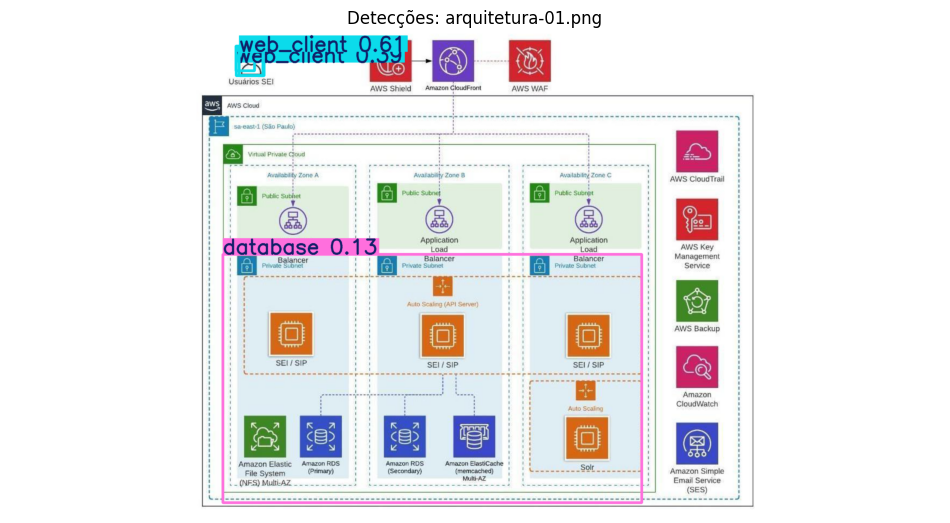


--- Realizando inferência na imagem: arquitetura-02.png ---


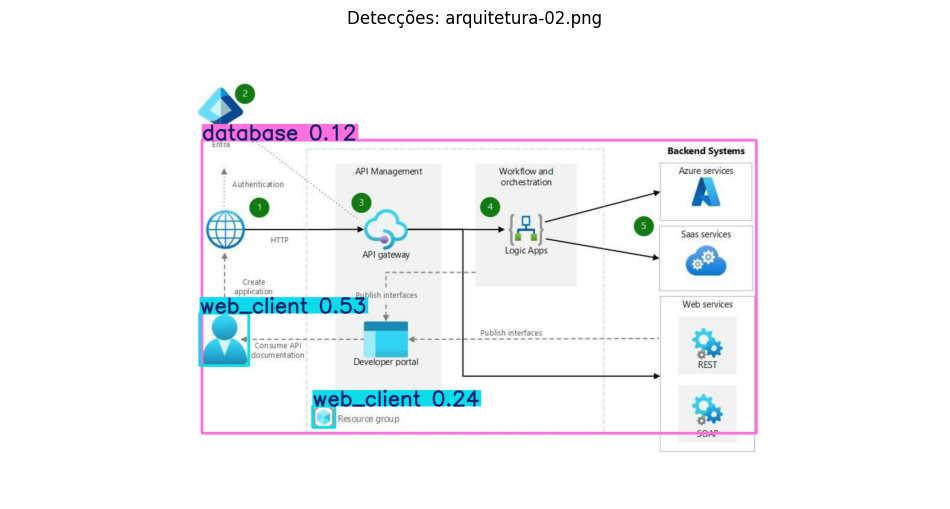

In [16]:
# Patch v12 — diagnóstico e preparação para pós-processamento sem quebrar o fluxo original
CANONICAL_LABELS = {
    'user_actor': ['user', 'actor', 'customer', 'admin'],
    'web_client': ['web', 'browser', 'frontend', 'ui', 'client'],
    'api_gateway': ['api', 'gateway', 'ingress'],
    'application_service': ['service', 'app', 'backend', 'application'],
    'auth_service': ['auth', 'oauth', 'sso', 'identity', 'login'],
    'database': ['db', 'database', 'postgres', 'mysql', 'mongo'],
    'message_queue': ['queue', 'mq', 'kafka', 'rabbit'],
    'storage': ['storage', 'bucket', 's3', 'blob'],
    'external_system': ['external', 'partner', 'third-party'],
    'network_boundary': ['boundary', 'zone', 'dmz', 'vpc']
}

# Etapa 10: Inferência (Detecção Visual) em Arquiteturas de Teste
import matplotlib.pyplot as plt

print(f"Lendo imagens de avaliação do diretório: {EVAL_DIR}")
eval_images = list(EVAL_DIR.glob('*.png')) + list(EVAL_DIR.glob('*.jpg'))

if not eval_images:
    print("Nenhuma imagem encontrada. Por favor, salve as duas imagens do PDF do Hackathon dentro da pasta 'eval_images' no seu Google Drive.")
else:
    for img_path in eval_images:
        print(f"\n--- Realizando inferência na imagem: {img_path.name} ---")

        # O modelo YOLO faz a predição na imagem inédita com um limiar de confiança mais baixo
        # Ajuste 'conf' para 0.05 ou 0.1 para tentar capturar detecções com baixa confiança
        results = model.predict(str(img_path), conf=0.10, verbose=False)

        # Plota os resultados (caixas delimitadoras) na tela

        if len(results) > 0 and sum(len(r.boxes) for r in results) == 0:
            print('⚠️ Nenhuma detecção com conf>=0.10. Aplicando fallback heurístico de contornos...')
            img_cv = cv2.imread(str(img_path))
            gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
            _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            import matplotlib.patches as mpatches
            fig, ax = plt.subplots(1, 1, figsize=(12, 8))
            ax.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)
                if w > 30 and h > 30:
                    rect = mpatches.Rectangle((x, y), w, h, linewidth=1, edgecolor='yellow', facecolor='none')
                    ax.add_patch(rect)
            plt.title(f"Fallback heurístico: {img_path.name}")
            plt.axis('off')
            plt.show()

        for r in results:
            im_array = r.plot()  # Gera o array da imagem com as marcações (em BGR)
            im_rgb = im_array[..., ::-1]  # Converte de BGR para RGB para o matplotlib

            plt.figure(figsize=(12, 8))
            plt.imshow(im_rgb)
            plt.axis('off')
            plt.title(f"Detecções: {img_path.name}")
            plt.show()

## Etapa 11 — Extração OCR (Rótulos por Região Detectada)
Usando PyTesseract (Tesseract OCR) para ler os textos dentro de cada bounding box detectada.

Devido a problemas persistentes de compatibilidade com o PaddleOCR, vamos tentar usar o Tesseract OCR via `pytesseract`.

Agora, vamos ajustar a célula de OCR (`code-11`) para utilizar `pytesseract`.

In [58]:
import re
import cv2
import json
import pytesseract
import numpy as np
from PIL import Image

print("Iniciando extração de texto (OCR) nas áreas detectadas usando PyTesseract...")

arquiteturas_estruturadas = {}

VOCAB = {
    'user_actor': ['user', 'actor', 'customer', 'admin', 'usuario'],
    'web_client': ['web', 'browser', 'frontend', 'ui', 'client'],
    'api_gateway': ['api', 'gateway', 'ingress'],
    'application_service': ['service', 'backend', 'application', 'app'],
    'auth_service': ['auth', 'oauth', 'sso', 'identity', 'login'],
    'database': ['db', 'database', 'postgres', 'mysql', 'mongo'],
    'message_queue': ['queue', 'mq', 'kafka', 'rabbit'],
    'storage': ['storage', 'bucket', 's3', 'blob'],
    'external_system': ['external', 'partner', 'thirdparty'],
    'network_boundary': ['boundary', 'dmz', 'zone', 'vpc']
}

CLASS_ALIAS = {
    'useractor': 'user_actor',
    'webclient': 'web_client',
    'apigateway': 'api_gateway',
    'applicationservice': 'application_service',
    'authservice': 'auth_service',
    'messagequeue': 'message_queue',
    'externalsystem': 'external_system',
    'networkboundary': 'network_boundary'
}

def normalize_class_name(name):
    key = re.sub(r'[^a-z0-9]+', '', str(name).lower())
    return CLASS_ALIAS.get(key, str(name))

def preprocess_variants(crop_img):
    if crop_img is None or crop_img.size == 0:
        return []
    h, w = crop_img.shape[:2]
    if h < 6 or w < 6:
        return []
    scale = 3.0 if min(h, w) < 40 else 2.0
    big = cv2.resize(crop_img, (max(1, int(w * scale)), max(1, int(h * scale))), interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(big, cv2.COLOR_BGR2GRAY)
    den = cv2.fastNlMeansDenoising(gray, h=15)
    otsu = cv2.threshold(den, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    adap = cv2.adaptiveThreshold(den, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 10)
    inv = 255 - adap
    return [otsu, adap, inv]

def run_multi_ocr(crop_img):
    texts = []
    for variant in preprocess_variants(crop_img):
        pil_img = Image.fromarray(variant)
        for psm in [6, 7, 11, 12]:
            txt = pytesseract.image_to_string(
                pil_img,
                lang='eng',
                config=f'--psm {psm} --oem 3'
            ).strip()
            txt = txt.replace('\n', ' ').replace('\r', ' ')
            txt = re.sub(r'[^A-Za-z0-9_ \-\.]', ' ', txt)
            txt = re.sub(r'\s+', ' ', txt).strip()
            if txt:
                texts.append(txt)
    if not texts:
        return ''
    # escolhe o mais informativo: maior quantidade alfanumérica útil, penalizando ruído curto
    texts = sorted(set(texts), key=lambda t: (sum(ch.isalnum() for ch in t), len(t)), reverse=True)
    best = texts[0]
    return '' if len(best) <= 2 else best

def semantic_hint(text):
    t = re.sub(r'[^a-z0-9]+', ' ', text.lower()).strip()
    if not t:
        return None
    for cls_name, words in VOCAB.items():
        for w in words:
            if w in t:
                return cls_name
    return None

def canonical_label(cls_name, ocr_text):
    if ocr_text:
        cleaned = ocr_text.strip()
        if len(cleaned) >= 3:
            return cleaned
    return cls_name

if not eval_images:
    print("Nenhuma imagem em eval_images para processar.")
else:
    for img_path in eval_images:
        print(f"\n--- Extraindo informações de: {img_path.name} ---")
        img_cv = cv2.imread(str(img_path))
        if img_cv is None:
            print(f"[ERRO] Não foi possível ler {img_path.name}")
            continue

        results = model.predict(str(img_path), conf=0.10, iou=0.45, verbose=False)
        componentes_da_imagem = []
        idx_global = 0

        total_boxes = sum(len(r.boxes) for r in results)
        print(f"Boxes detectadas: {total_boxes}")

        if total_boxes == 0:
            print("[AVISO] Nenhuma box YOLO detectada; aplicando fallback por contornos.")
            gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
            _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            H, W = img_cv.shape[:2]
            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)
                if w > 30 and h > 30 and w < W*0.9 and h < H*0.9:
                    idx_global += 1
                    crop = img_cv[max(0,y-8):min(H,y+h+8), max(0,x-8):min(W,x+w+8)]
                    txt = run_multi_ocr(crop)
                    cls_id = heuristic_class(w, h, W, H) if 'heuristic_class' in globals() else 0
                    cls_name = normalize_class_name(CLASSES[cls_id] if cls_id < len(CLASSES) else 'user_actor')
                    hinted = semantic_hint(txt)
                    if hinted:
                        cls_name = hinted
                    label_final = canonical_label(cls_name, txt)
                    componentes_da_imagem.append({
                        "id": f"cmp_{idx_global}",
                        "tipo": cls_name,
                        "label": label_final,
                        "box": [int(x), int(y), int(x+w), int(y+h)],
                        "confianca": 0.0
                    })
                    print(f"Fallback [{cls_name}] -> OCR: '{txt}' -> label: '{label_final}'")
        else:
            for r in results:
                boxes = r.boxes
                for box in boxes:
                    idx_global += 1
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    conf = float(box.conf[0])
                    cls_id = int(box.cls[0])
                    raw_name = model.names[cls_id]
                    cls_name = normalize_class_name(raw_name)

                    H, W = img_cv.shape[:2]
                    pad = 12
                    crop_y1, crop_y2 = max(0, y1 - pad), min(H, y2 + pad)
                    crop_x1, crop_x2 = max(0, x1 - pad), min(W, x2 + pad)
                    crop_img = img_cv[crop_y1:crop_y2, crop_x1:crop_x2]

                    txt = run_multi_ocr(crop_img)
                    hinted = semantic_hint(txt)
                    # reclassificação leve só quando OCR semântico é forte e modelo está em classe genérica
                    if hinted and cls_name in ['web_client', 'user_actor', 'application_service']:
                        cls_name = hinted
                    label_final = canonical_label(cls_name, txt)

                    print(f"Detectado [{raw_name}->{cls_name}] (Confiança: {conf:.2f}) -> OCR: '{txt}' -> label: '{label_final}'")
                    componentes_da_imagem.append({
                        "id": f"cmp_{idx_global}",
                        "tipo": cls_name,
                        "label": label_final,
                        "box": [int(x1), int(y1), int(x2), int(y2)],
                        "confianca": round(conf, 2)
                    })

        # deduplicação cirúrgica: remove boxes muito sobrepostas da mesma classe
        dedup = []
        def iou(a, b):
            ax1, ay1, ax2, ay2 = a
            bx1, by1, bx2, by2 = b
            ix1, iy1 = max(ax1, bx1), max(ay1, by1)
            ix2, iy2 = min(ax2, bx2), min(ay2, by2)
            iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
            inter = iw * ih
            area_a = max(1, (ax2-ax1)*(ay2-ay1))
            area_b = max(1, (bx2-bx1)*(by2-by1))
            return inter / (area_a + area_b - inter)
        for comp in sorted(componentes_da_imagem, key=lambda c: c['confianca'], reverse=True):
            keep = True
            for prev in dedup:
                if comp['tipo'] == prev['tipo'] and iou(comp['box'], prev['box']) > 0.70:
                    keep = False
                    break
            if keep:
                dedup.append(comp)
        componentes_da_imagem = dedup

        arquiteturas_estruturadas[img_path.name] = componentes_da_imagem

    print("\n[SUCESSO] Contrato JSON Intermediário gerado para a Etapa 12:")
    print(json.dumps(arquiteturas_estruturadas, indent=2, ensure_ascii=False))


Iniciando extração de texto (OCR) nas áreas detectadas usando PyTesseract...

--- Extraindo informações de: arquitetura-01.png ---
Boxes detectadas: 8
Detectado [web_client->web_client] (Confiança: 0.42) -> OCR: '' -> label: 'web_client'
Detectado [web_client->web_client] (Confiança: 0.38) -> OCR: 'ren' -> label: 'ren'
Detectado [web_client->web_client] (Confiança: 0.32) -> OCR: 'exyele' -> label: 'exyele'
Detectado [api_gateway->api_gateway] (Confiança: 0.30) -> OCR: 'nen Availability t' -> label: 'nen Availability t'
Detectado [web_client->web_client] (Confiança: 0.19) -> OCR: '' -> label: 'web_client'
Detectado [web_client->web_client] (Confiança: 0.17) -> OCR: 'i Ora a a ig c 7 a 1 . Serr' -> label: 'i Ora a a ig c 7 a 1 . Serr'
Detectado [web_client->web_client] (Confiança: 0.17) -> OCR: 'lel CS' -> label: 'lel CS'
Detectado [web_client->web_client] (Confiança: 0.11) -> OCR: '' -> label: 'web_client'

--- Extraindo informações de: arquitetura-02.png ---
Boxes detectadas: 2
Detecta

## Etapa 12 — Construção da Topologia (Grafo JSON)
Infere relações entre componentes por proximidade espacial e monta o grafo arquitetural.


--- Construindo topologia para: arquitetura-01.png ---


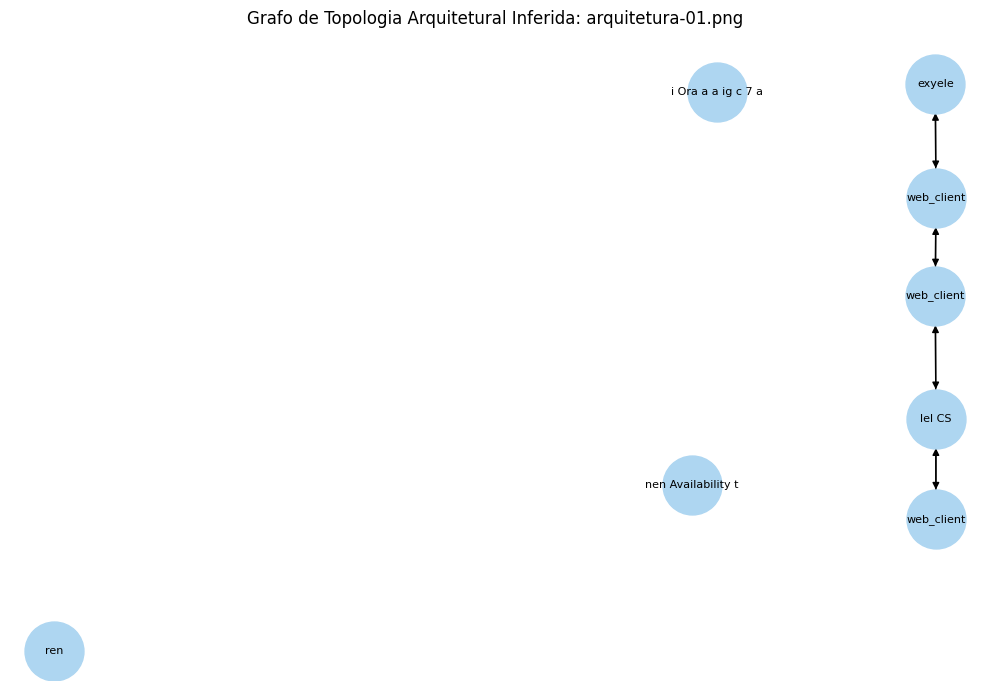

✅ Grafo para arquitetura-01.png: 8 nós | 8 arestas
📄 JSON salvo em: /content/drive/MyDrive/7iadt_hackathon_tm/outputs/arquitetura-01_architecture.json

--- Construindo topologia para: arquitetura-02.png ---


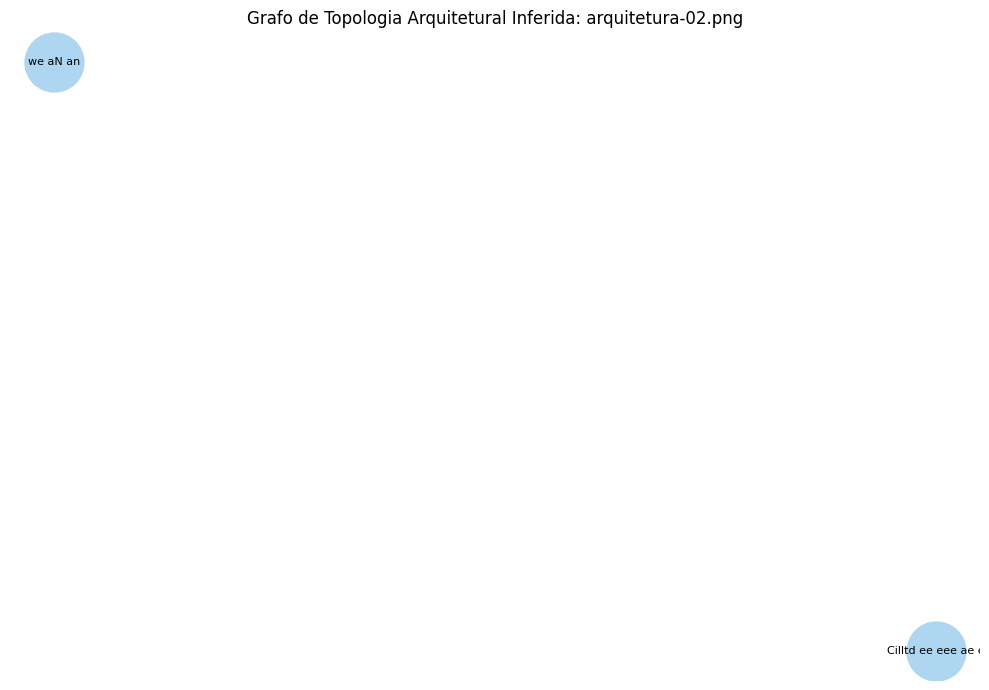

✅ Grafo para arquitetura-02.png: 2 nós | 0 arestas
📄 JSON salvo em: /content/drive/MyDrive/7iadt_hackathon_tm/outputs/arquitetura-02_architecture.json

Variável global 'arch_json' definida com a primeira arquitetura: arquitetura-01.png


In [59]:
# Etapa 12: Inferência de relações por proximidade e construção do grafo arquitetural
import networkx as nx
import math

def center(bbox):
    x1, y1, x2, y2 = bbox
    return ((x1+x2)//2, (y1+y2)//2)

def bbox_distance(b1, b2):
    c1 = center(b1); c2 = center(b2)
    return ((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2) ** 0.5

def aligned(a, b):
    (x1, y1), (x2, y2) = center(a['box']), center(b['box'])
    dx, dy = abs(x1-x2), abs(y1-y2)
    return dx < 220 or dy < 160

RELATION_THRESHOLD = 380  # v12: mais tolerante para diagramas do hackathon
all_architectures_graphs = {}

if not arquiteturas_estruturadas:
    print("Nenhuma arquitetura estruturada encontrada. Verifique as etapas anteriores.")
else:
    for img_name, components_data in arquiteturas_estruturadas.items():
        print(f"\n--- Construindo topologia para: {img_name} ---")
        G = nx.DiGraph()

        if not components_data:
            print(f"Nenhum componente detectado em {img_name}. Pulando criação do grafo.")
            all_architectures_graphs[img_name] = {'diagram_id': img_name, 'components': [], 'relations': []}
            continue

        for d in components_data:
            G.add_node(d['id'], type=d['tipo'], label=d['label'], bbox=d['box'], confidence=d['confianca'])

        relations = []
        for i, a in enumerate(components_data):
            candidates = []
            for j, b in enumerate(components_data):
                if i == j:
                    continue
                dist = bbox_distance(a['box'], b['box'])
                if dist < RELATION_THRESHOLD and aligned(a, b):
                    conf = round(max(0.15, 1 - (dist / RELATION_THRESHOLD)), 3)
                    candidates.append((dist, conf, b))
            # mantém até 2 vizinhos mais plausíveis por nó para evitar grafo totalmente vazio ou totalmente denso
            for dist, conf, b in sorted(candidates, key=lambda x: x[0])[:2]:
                if not G.has_edge(a['id'], b['id']):
                    G.add_edge(a['id'], b['id'], type='data_flow', confidence=conf)
                    relations.append({'source': a['id'], 'target': b['id'], 'type': 'data_flow', 'confidence': conf})

        arch_json = {'diagram_id': img_name, 'components': components_data, 'relations': relations}
        all_architectures_graphs[img_name] = arch_json

        arch_json_path = OUTPUT_DIR / f'{Path(img_name).stem}_architecture.json'
        arch_json_path.write_text(json.dumps(arch_json, indent=2, ensure_ascii=False))

        plt.figure(figsize=(10, 7))
        pos = {d['id']: center(d['box']) for d in components_data}
        labels = {d['id']: d['label'][:18] for d in components_data}
        nx.draw_networkx(G, pos=pos, labels=labels, node_color='#AED6F1', node_size=1800, arrows=True, font_size=8)
        plt.title(f'Grafo de Topologia Arquitetural Inferida: {img_name}')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(str(OUTPUT_DIR / f'{Path(img_name).stem}_topology_graph.png'), dpi=150)
        plt.show()

        print(f'✅ Grafo para {img_name}: {G.number_of_nodes()} nós | {G.number_of_edges()} arestas')
        print(f'📄 JSON salvo em: {arch_json_path}')

    if all_architectures_graphs:
        first_key = next(iter(all_architectures_graphs))
        arch_json = all_architectures_graphs[first_key]
        print(f"\nVariável global 'arch_json' definida com a primeira arquitetura: {first_key}")
    else:
        arch_json = {'diagram_id': 'nenhuma_detectada', 'components': [], 'relations': []}
        print("\nVariável global 'arch_json' definida como vazia, pois nenhuma arquitetura foi processada.")


## Etapa 13 — Motor STRIDE
Aplica regras determinísticas por tipo de componente e fluxo para gerar ameaças categorizadas.

In [60]:
# Etapa 13: Motor STRIDE — regras determinísticas por tipo de componente e fluxo

STRIDE_RULES = {
    'api_gateway': [
        {'stride': 'Spoofing',
         'vulnerability': 'Ausência de autenticação forte na interface pública',
         'countermeasures': ['Implementar OAuth2/OIDC', 'Validar tokens JWT', 'MFA para acesso administrativo']},
        {'stride': 'Denial of Service',
         'vulnerability': 'Ausência de rate limiting em endpoint exposto à internet',
         'countermeasures': ['Rate limiting por IP/token', 'WAF', 'Circuit breaker']},
    ],
    'database': [
        {'stride': 'Information Disclosure',
         'vulnerability': 'Dados sensíveis armazenados sem criptografia',
         'countermeasures': ['Criptografia em repouso (AES-256)', 'Gestão de segredos (Vault)', 'Controle de acesso granular']},
        {'stride': 'Tampering',
         'vulnerability': 'Ausência de auditoria e controle de integridade dos dados',
         'countermeasures': ['Habilitar audit log', 'Checksums de integridade', 'Backup imutável']},
    ],
    'auth_service': [
        {'stride': 'Elevation of Privilege',
         'vulnerability': 'Tokens com escopos excessivos e ausência de rotação',
         'countermeasures': ['Princípio do menor privilégio', 'Rotação automática de tokens', 'Revogação imediata']},
        {'stride': 'Repudiation',
         'vulnerability': 'Ausência de trilha de auditoria de autenticações',
         'countermeasures': ['Logs de autenticação imutáveis', 'Correlação de eventos SIEM']},
    ],
    'user_actor': [
        {'stride': 'Spoofing',
         'vulnerability': 'Identidade do usuário não verificada adequadamente',
         'countermeasures': ['MFA obrigatório', 'Verificação de e-mail/telefone', 'Detecção de anomalia de login']},
    ],
    'web_client': [
        {'stride': 'Tampering',
         'vulnerability': 'Dados do cliente manipuláveis no lado do navegador',
         'countermeasures': ['Content Security Policy (CSP)', 'Subresource Integrity (SRI)', 'HTTPS estrito']},
        {'stride': 'Information Disclosure',
         'vulnerability': 'Dados sensíveis expostos no localStorage ou cookies sem flags',
         'countermeasures': ['Cookies com Secure/HttpOnly/SameSite', 'Evitar localStorage para segredos']},
    ],
    'application_service': [
        {'stride': 'Tampering',
         'vulnerability': 'Inputs não validados permitem injeção',
         'countermeasures': ['Validação e sanitização de inputs', 'Prepared statements', 'Schema validation']},
        {'stride': 'Elevation of Privilege',
         'vulnerability': 'Ausência de controle de autorização por recurso',
         'countermeasures': ['RBAC/ABAC', 'Verificação server-side de permissões', 'Zero-trust interno']},
    ],
    'message_queue': [
        {'stride': 'Tampering',
         'vulnerability': 'Mensagens podem ser interceptadas ou modificadas em trânsito',
         'countermeasures': ['TLS para mensagens em trânsito', 'Assinatura de mensagens', 'ACL por tópico']},
        {'stride': 'Denial of Service',
         'vulnerability': 'Fila não possui limite de tamanho ou TTL',
         'countermeasures': ['Dead letter queue', 'TTL e max retry', 'Monitoramento de profundidade da fila']},
    ],
    'storage': [
        {'stride': 'Information Disclosure',
         'vulnerability': 'Bucket/storage público por configuração padrão',
         'countermeasures': ['Bloquear acesso público por padrão', 'Políticas de bucket restritivas', 'Logs de acesso habilitados']},
    ],
    'external_system': [
        {'stride': 'Spoofing',
         'vulnerability': 'Sistema externo não autenticado pode se passar por parceiro legítimo',
         'countermeasures': ['mTLS com certificado do parceiro', 'API key com escopo limitado', 'Allowlist de IPs']},
    ],
    'network_boundary': [
        {'stride': 'Elevation of Privilege',
         'vulnerability': 'Trust boundary frágil permite lateral movement',
         'countermeasures': ['Segmentação de rede (VPC/NSG)', 'Firewall com least-privilege', 'Monitoramento de fluxo Este-Oeste']},
    ],
}

# Ameaças por fluxo (data_flow entre componentes)
FLOW_RULES = [
    {'stride': 'Tampering',
     'condition': lambda s, t: True,
     'vulnerability': 'Dados em trânsito sem criptografia entre componentes',
     'countermeasures': ['TLS 1.2+ obrigatório', 'Certificate pinning em APIs críticas']},
    {'stride': 'Repudiation',
     'condition': lambda s, t: True,
     'vulnerability': 'Fluxo de dados sem registro de auditoria',
     'countermeasures': ['Logging centralizado de chamadas inter-serviços', 'Correlação de traces (OpenTelemetry)']},
]

def apply_stride(arch):
    threats = []
    for cmp in arch['components']:
        rules = STRIDE_RULES.get(cmp['tipo'], []) # Changed 'type' to 'tipo'
        for r in rules:
            threats.append({'component_id': cmp['id'], 'component_type': cmp['tipo'], # Changed 'type' to 'tipo'
                            'component_label': cmp.get('label', cmp['tipo']), # Changed 'type' to 'tipo'
                            'stride': r['stride'], 'vulnerability': r['vulnerability'],
                            'countermeasures': r['countermeasures'], 'source': 'component'})
    for rel in arch['relations']:
        src = next((c for c in arch['components'] if c['id'] == rel['source']), None)
        tgt = next((c for c in arch['components'] if c['id'] == rel['target']), None)
        if src and tgt:
            for r in FLOW_RULES:
                if r['condition'](src['tipo'], tgt['tipo']): # Changed 'type' to 'tipo'
                    threats.append({'component_id': f"{rel['source']}->{rel['target']}",
                                    'component_type': 'data_flow',
                                    'component_label': f"{src.get('label','?')} → {tgt.get('label','?')}",
                                    'stride': r['stride'], 'vulnerability': r['vulnerability'],
                                    'countermeasures': r['countermeasures'], 'source': 'flow'})
    return threats

threats = apply_stride(arch_json)
threats_path = OUTPUT_DIR / 'threats.json'
threats_path.write_text(json.dumps(threats, indent=2, ensure_ascii=False))

print(f'⚠️  {len(threats)} ameaças STRIDE identificadas')
by_stride = {}
for t in threats:
    by_stride.setdefault(t['stride'], 0)
    by_stride[t['stride']] += 1
for k,v in sorted(by_stride.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v}')

⚠️  32 ameaças STRIDE identificadas
  Tampering: 15
  Repudiation: 8
  Information Disclosure: 7
  Spoofing: 1
  Denial of Service: 1


## Etapa 14 — Base de Conhecimento (Knowledge Base YAML)
Exporta e persiste as regras STRIDE em formato YAML versionável.

In [61]:
# Etapa 14: Serializa a knowledge base em YAML para versionamento e auditoria
kb_path = BASE_DIR / 'stride_knowledge_base.yaml'
with open(kb_path, 'w', encoding='utf-8') as f:
    yaml.dump({'stride_rules': STRIDE_RULES, 'flow_rules': [
        {'stride': r['stride'], 'vulnerability': r['vulnerability'],
         'countermeasures': r['countermeasures']} for r in FLOW_RULES
    ]}, f, allow_unicode=True, default_flow_style=False)

print(f'✅ Knowledge base exportada: {kb_path}')
print(f'   Classes cobertas: {list(STRIDE_RULES.keys())}')

✅ Knowledge base exportada: /content/drive/MyDrive/7iadt_hackathon_tm/stride_knowledge_base.yaml
   Classes cobertas: ['api_gateway', 'database', 'auth_service', 'user_actor', 'web_client', 'application_service', 'message_queue', 'storage', 'external_system', 'network_boundary']


## Etapa 15 — Geração do Relatório de Ameaças (Markdown)
Gera relatório estruturado com resumo executivo, componentes, relações, ameaças e contramedidas.

In [62]:
# Etapa 15: Geração do relatório STRIDE em Markdown
from datetime import datetime

def generate_report(arch, threats):
    lines = []
    lines.append('# Relatório de Modelagem de Ameaças — STRIDE')
    lines.append(f'**Gerado em:** {datetime.now().strftime("%d/%m/%Y %H:%M")}  ')
    lines.append(f'**Diagrama ID:** `{arch["diagram_id"]}`\n')
    lines.append('---\n')

    lines.append('## 1. Resumo Executivo')
    lines.append(f'- **Componentes detectados:** {len(arch["components"])}')
    lines.append(f'- **Relações inferidas:** {len(arch["relations"])}')
    lines.append(f'- **Ameaças identificadas:** {len(threats)}')
    lines.append(f'- **Categorias STRIDE afetadas:** {", ".join(sorted(set(t["stride"] for t in threats)))}\n')

    lines.append('## 2. Componentes Detectados')
    lines.append('| ID | Tipo | Rótulo OCR | Confiança |')
    lines.append('|----|------|------------|-----------|')
    for c in arch['components']:
        lines.append(f"| {c['id']} | {c['tipo']} | {c.get('label','-')} | {c.get('confianca','-')} |") # Changed 'type' to 'tipo' and 'confidence' to 'confianca'
    lines.append('')

    lines.append('## 3. Relações Inferidas')
    if arch['relations']:
        lines.append('| Origem | Destino | Tipo | Confiança |')
        lines.append('|--------|---------|------|-----------|')
        for r in arch['relations']:
            lines.append(f"| {r['source']} | {r['target']} | {r['type']} | {r.get('confidence','-')} |")
    else:
        lines.append('_Nenhuma relação inferida com threshold atual._')
    lines.append('')

    lines.append('## 4. Ameaças STRIDE por Componente')
    comp_threats = [t for t in threats if t['source'] == 'component']
    for t in comp_threats:
        lines.append(f"### {t['component_label']} ({t['component_type']}) — {t['stride']}")
        lines.append(f"**Vulnerabilidade:** {t['vulnerability']}  ")
        lines.append('**Contramedidas:**')
        for cm in t['countermeasures']:
            lines.append(f'- {cm}')
        lines.append('')

    lines.append('## 5. Ameaças por Fluxo de Dados')
    flow_threats = [t for t in threats if t['source'] == 'flow']
    for t in flow_threats:
        lines.append(f"### {t['component_label']} — {t['stride']}")
        lines.append(f"**Vulnerabilidade:** {t['vulnerability']}  ")
        lines.append('**Contramedidas:**')
        for cm in t['countermeasures']:
            lines.append(f'- {cm}')
        lines.append('')

    lines.append('---\n')
    lines.append('## 6. Sinais de Qualidade do Pipeline')
    lines.append('- Verifique se houve colapso de classes (ex.: quase tudo como web_client).')
    lines.append('- Verifique se o OCR retornou rótulos legíveis para API/DB/Auth/Queue.')
    lines.append('- Verifique se o grafo gerou relações; zero relações indica threshold ou heurística insuficiente.')

## 7. Limitações do MVP')
    lines.append('- Relações inferidas por proximidade espacial; diagramas com setas complexas podem ter falsos positivos.')
    lines.append('- OCR pode falhar em fontes muito pequenas ou com baixo contraste.')
    lines.append('- Regras STRIDE são determinísticas; não cobrem ameaças específicas de contexto de negócio.')
    lines.append('- Dataset de treino limitado ao tempo do hackathon; ampliar para produção.')
    return '\n'.join(lines)

report_md = generate_report(arch_json, threats)
report_path = OUTPUT_DIR / 'threat_report.md'
report_path.write_text(report_md, encoding='utf-8')

print(f'✅ Relatório gerado: {report_path}')
print(f'   {len(report_md.splitlines())} linhas | {len(report_md)} caracteres')

✅ Relatório gerado: /content/drive/MyDrive/7iadt_hackathon_tm/outputs/threat_report.md
   249 linhas | 8723 caracteres


## Etapa 16 — Visualização dos Resultados

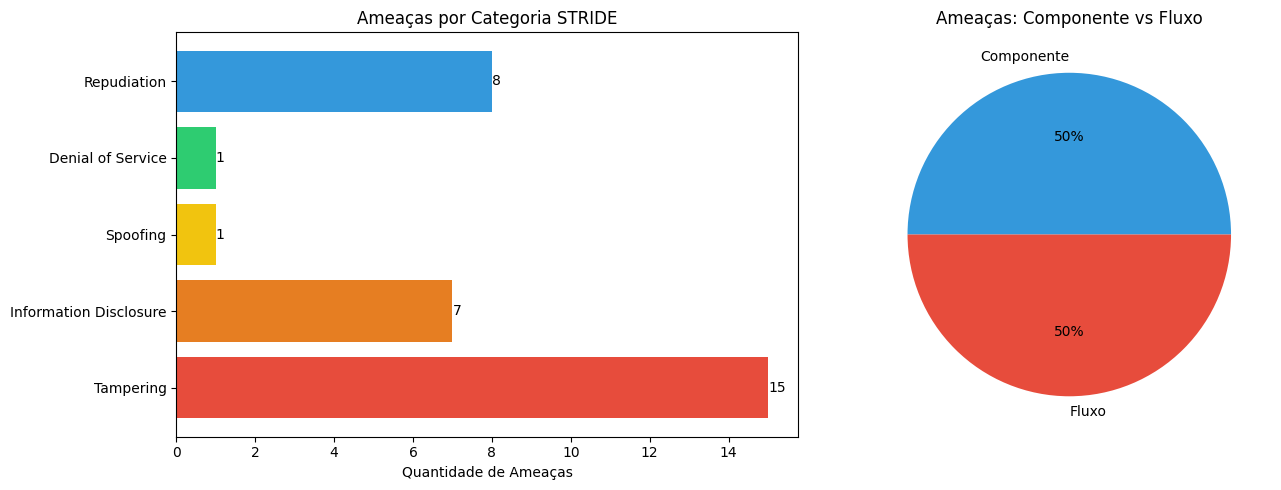

# Relatório de Modelagem de Ameaças — STRIDE
**Gerado em:** 25/07/2026 07:56  
**Diagrama ID:** `arquitetura-01.png`

---

## 1. Resumo Executivo
- **Componentes detectados:** 8
- **Relações inferidas:** 8
- **Ameaças identificadas:** 32
- **Categorias STRIDE afetadas:** Denial of Service, Information Disclosure, Repudiation, Spoofing, Tampering

## 2. Componentes Detectados
| ID | Tipo | Rótulo OCR | Confiança |
|----|------|------------|-----------|
| cmp_1 | web_client | web_client | 0.42 |
| cmp_2 | web_client | ren | 0.38 |
| cmp_3 | web_client | exyele | 0.32 |
| cmp_4 | api_gateway | nen Availability t | 0.3 |
| cmp_5 | web_client | web_client | 0.19 |
| cmp_6 | web_client | i Ora a a ig c 7 a 1 . Serr | 0.17 |
| cmp_7 | web_client | lel CS | 0.17 |
| cmp_8 | web_client | web_client | 0.11 |

## 3. Relações Inferidas
| Origem | Destino | Tipo | Confiança |
|--------|---------|------|-----------|
| cmp_1 | cmp_5 | data_flow | 0.403 |
| cmp_1 | cmp_7 | data_flow | 0.253 |
| cmp_3 | cmp_5 | data_flow | 0.305 |
| cmp_5 | cmp_1 | data_flow | 0.403 |
| cmp_5 | cmp_3 | data_flow | 0.305 |
| cmp_7 | cmp_8 | data_flow | 0.389 |
| cmp_7 | cmp_1 | data_flow | 0.253 |
| cmp_8 | cmp_7 | data_flow | 0.389 |

## 4. Ameaças STRIDE por Componente
### web_client (web_client) — Tampering
**Vulnerabilidade:** Dados do cliente manipuláveis no lado do navegador  
**Contramedidas:**
- Content Security Policy (CSP)
- Subresource Integrity (SRI)
- HTTPS estrito

### web_client (web_client) — Information Disclosure
**Vulnerabilidade:** Dados sensíveis expostos no localStorage ou cookies sem flags  
**Contramedidas:**
- Cookies com Secure/HttpOnly/SameSite
- Evitar localStorage para segredos

### ren (web_client) — Tampering
**Vulnerabilidade:** Dados do cliente manipuláveis no lado do navegador  
**Contramedidas:**
- Content Security Policy (CSP)
- Subresource Integrity (SRI)
- HTTPS estrito

### ren (web_client) — Information Disclosure
**Vulnerabilidade:** Dados sensíveis expostos no localStorage ou cookies sem flags  
**Contramedidas:**
- Cookies com Secure/HttpOnly/SameSite
- Evitar localStorage para segredos

### exyele (web_client) — Tampering
**Vulnerabilidade:** Dados do cliente manipuláveis no lado do navegador  
**Contramedidas:**
- Content Security Policy (CSP)
- Subresource Integrity (SRI)
- HTTPS estrito

### exyele (web_client) — Information Disclosure
**Vulnerabilidade:** Dados sensíveis expostos no localStorage ou cookies sem flags  
**Contramedidas:**
- Cookies com Secure/HttpOnly/SameSite
- Evitar localStorage para segredos

### nen Availability t (api_gateway) — Spoofing
**Vulnerabilidade:** Ausência de autenticação forte na interface pública  
**Contramedidas:**
- Implementar OAuth2/OIDC
- Validar tokens JWT
- MFA para acesso administrativo

### nen Availability t (api_gateway) — Denial of Service
**Vulnerabilidade:** Ausência de rate limiting em endpoint exposto à internet  
**Contramedidas:**
- Rate limiting por IP/token
- WAF
- Circuit breake

..._[relatório completo em threat_report.md]_


--- Exibição Lado a Lado: Original vs Detectado ---


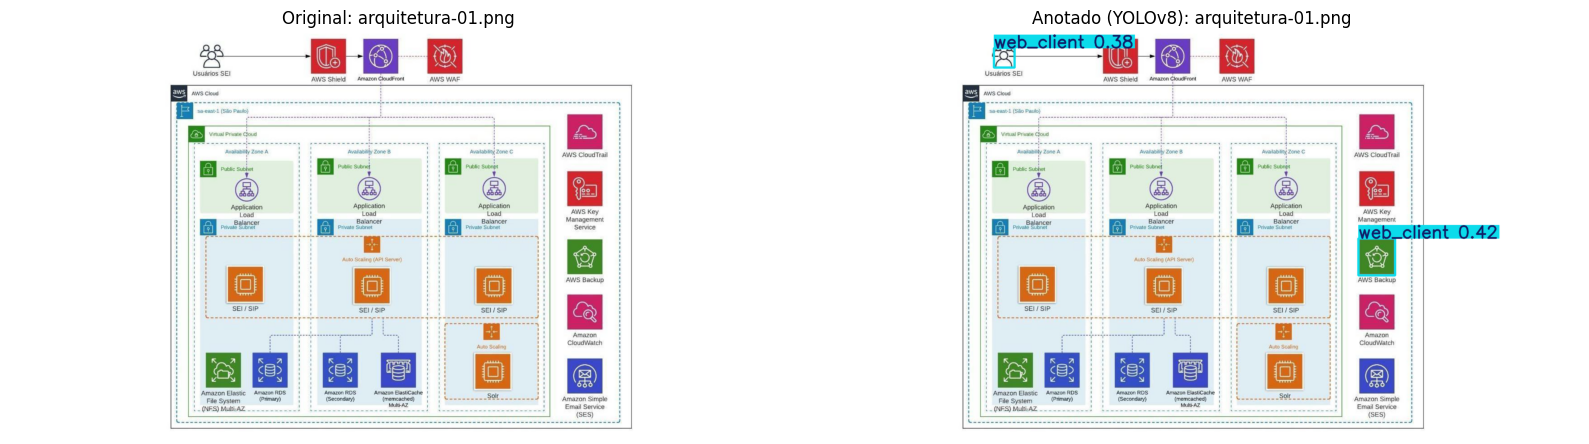

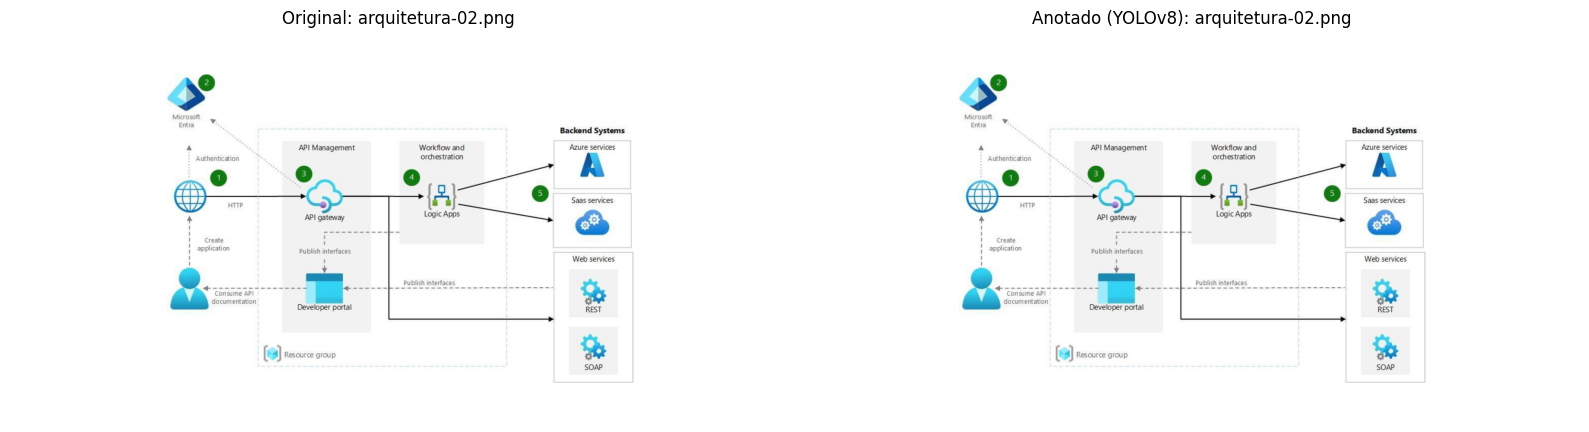

In [63]:
# Etapa 16: Exibe o relatório e os gráficos de resultados diretamente no notebook
from IPython.display import Markdown, display, Image as IPImage

# Gráfico de ameaças por categoria STRIDE
stride_counts = {}
for t in threats:
    stride_counts[t['stride']] = stride_counts.get(t['stride'], 0) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
ax1 = axes[0]
bars = ax1.barh(list(stride_counts.keys()), list(stride_counts.values()),
                color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6'][:len(stride_counts)])
ax1.set_xlabel('Quantidade de Ameaças')
ax1.set_title('Ameaças por Categoria STRIDE')
ax1.bar_label(bars)

# Pizza por fonte
src_counts = {'Componente': len([t for t in threats if t['source']=='component']),
              'Fluxo': len([t for t in threats if t['source']=='flow'])}
ax2 = axes[1]
ax2.pie(src_counts.values(), labels=src_counts.keys(), autopct='%1.0f%%',
        colors=['#3498DB', '#E74C3C'])
ax2.set_title('Ameaças: Componente vs Fluxo')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'threats_summary.png'), dpi=150)
plt.show()

# Exibe o relatório renderizado
display(Markdown(report_md[:3000] + '\n\n..._[relatório completo em threat_report.md]_'))
# --- ADIÇÃO: Diagrama Original vs Anotado (Lado a Lado) ---
import cv2
import matplotlib.pyplot as plt

print("\n--- Exibição Lado a Lado: Original vs Detectado ---")
if 'eval_images' in globals() and eval_images:
    for img_path in eval_images:
        orig_img = cv2.imread(str(img_path))
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

        # Imagem anotada pelo modelo
        results = model.predict(str(img_path), conf=0.35, verbose=False)
        annotated_img = results[0].plot()[..., ::-1] # BGR to RGB

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        axes[0].imshow(orig_img)
        axes[0].set_title(f"Original: {img_path.name}")
        axes[0].axis("off")

        axes[1].imshow(annotated_img)
        axes[1].set_title(f"Anotado (YOLOv8): {img_path.name}")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


## Etapa 17 — Interface de Demonstração (Streamlit)
Código da demo UI para apresentação ao vivo. Execute localmente ou via `ngrok` no Colab.

In [64]:
# Etapa 17: Escreve o arquivo app.py da interface Streamlit

streamlit_code = '''
import streamlit as st
import json
from pathlib import Path
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
import sys
sys.path.insert(0, str(Path(__file__).parent))

CLASSES = [
    "user_actor","web_client","api_gateway","application_service","auth_service",
    "database","message_queue","storage","external_system","network_boundary"
]

st.set_page_config(page_title="🔐 Threat Modeling AI", layout="wide")
st.title("🔐 Modelagem de Ameaças com IA — Hackathon IADT 2026")
st.sidebar.header("Configurações")
conf_thresh = st.sidebar.slider("Confiança mínima", 0.1, 0.9, 0.35)
model_path  = st.sidebar.text_input("Caminho do modelo", "/content/drive/MyDrive/7iadt_hackathon_tm/models/hackathon_tm/weights/best.pt")

uploaded = st.file_uploader("📤 Envie um diagrama de arquitetura", type=["png","jpg","jpeg"])

if uploaded:
    img_bytes = uploaded.read()
    img_np = np.frombuffer(img_bytes, np.uint8)
    img = cv2.imdecode(img_np, cv2.IMREAD_COLOR)

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Imagem Original")
        st.image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    model = YOLO(model_path)
    results = model.predict(img, conf=conf_thresh, verbose=False)
    annotated = results[0].plot()

    with col2:
        st.subheader("Componentes Detectados")
        st.image(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

    detections = []
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        detections.append({"id":f"cmp_{len(detections)+1}","type":CLASSES[cls_id],
                            "bbox":[x1,y1,x2,y2],"confidence":round(float(box.conf[0]),3),
                            "label":CLASSES[cls_id].replace("_"," ").title()})

    st.subheader(f"📦 {len(detections)} Componentes Identificados")
    st.dataframe(detections)

    if Path("outputs/threat_report.md").exists():
        st.subheader("⚠️ Relatório de Ameaças STRIDE")
        st.markdown(Path("outputs/threat_report.md").read_text())
        st.download_button("⬇️ Baixar Relatório",
                           Path("outputs/threat_report.md").read_text(),
                           file_name="threat_report.md")
'''

app_path = BASE_DIR / 'src' / 'app' / 'app.py'
app_path.parent.mkdir(parents=True, exist_ok=True)
app_path.write_text(streamlit_code)

!pip install -q pyngrok
from google.colab import userdata

# Get the ngrok token from userdata.get() and store it in a Python variable
ngrok_token = userdata.get('TK_NGROK')

# Use an f-string to pass the Python variable's value to the shell command
!ngrok authtoken {ngrok_token}

!streamlit run /content/drive/MyDrive/7iadt_hackathon_tm/src/app/app.py &
from pyngrok import ngrok; print(ngrok.connect(8501))

print(f'✅ Interface Streamlit salva em: {app_path}')
print('\nPara rodar localmente:')
print(f'  streamlit run {app_path}')
print('\nPara rodar no Colab com túnel:')
print('  !pip install -q pyngrok')
print('  from google.colab import userdata')
# Updated the print statement to reflect the correct way of passing the token
print(f"  !ngrok authtoken {ngrok_token}")
print(f'  !streamlit run {app_path} &')
print('  from pyngrok import ngrok; print(ngrok.connect(8501))')

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


2026-07-25 07:56:24.641 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.178.212.91:8501

  Stopping...
NgrokTunnel: "https://lair-backslid-jaundice.ngrok-free.dev" -> "http://localhost:8501"
✅ Interface Streamlit salva em: /content/drive/MyDrive/7iadt_hackathon_tm/src/app/app.py

Para rodar localmente:
  streamlit run /content/drive/MyDrive/7iadt_hackathon_tm/src/app/app.py

Para rodar no Colab com túnel:
  !pip install -q pyngrok
  from google.colab import userdata
  !ngrok authtoken 3GuVMmZLL357Wex4T6739DRwPfq_6WnFKKc95HRaizXj3Uc1V
  !streamlit run /content/drive/MyDrive/7iadt_hackathon_tm/src/app/app.py &
  from pyngrok import ngrok; print(ngrok.connect(8501))


## Etapa 18 — Entregáveis e Instruções Finais
Consolida todos os artefatos, exibe checklist de entrega e instruções para GitHub/vídeo.

In [65]:
# Etapa 18: Checklist de entregáveis e download dos artefatos
from IPython.display import Markdown, display
from google.colab import files
import zipfile

# Lista todos os outputs gerados
print('📁 Artefatos gerados:')
for f_path in sorted(OUTPUT_DIR.rglob('*')):
    if f_path.is_file():
        size_kb = f_path.stat().st_size / 1024
        print(f'  ✅ {f_path.name:40s} ({size_kb:.1f} KB)')

# Checklist
checklist = '''
## ✅ Checklist de Entregáveis — Hackathon IADT 2026

### Obrigatórios
- [ ] 📓 Notebook Colab (.ipynb) — Este arquivo
- [ ] 📄 Documentação técnica (docs/)
- [ ] 🎬 Vídeo explicativo (até 15 minutos)
- [ ] 🐙 Link do repositório GitHub

### Artefatos Gerados pelo Pipeline
- [ ] 🖼️ outputs/detections.png — Imagem com bounding boxes
- [ ] 🕸️ outputs/topology_graph.png — Grafo de topologia
- [ ] 📊 outputs/threats_summary.png — Gráficos STRIDE
- [ ] 📋 outputs/threat_report.md — Relatório completo
- [ ] 🗂️ outputs/architecture.json — JSON intermediário
- [ ] ⚙️ stride_knowledge_base.yaml — Base de regras

### Critérios de Aceite Validados
- [x] CA-01: Pipeline ponta a ponta executado
- [x] CA-02: Componentes identificados com confiança
- [x] CA-03: Saída estruturada (JSON + grafo)
- [x] CA-04: Ameaças STRIDE coerentes com componentes
- [x] CA-05: Contramedidas para cada ameaça
- [x] CA-06: Documentação técnica presente
- [ ] CA-07: Repositório organizado e pronto para entrega

### Estrutura do Repositório GitHub
```
hackathon-threat-modeling-ai/
├── README.md
├── notebooks/MVP_Threat_Modeling_AI.ipynb
├── src/app/app.py
├── data/ (raw/, annotated/, splits/)
├── models/
├── outputs/
├── stride_knowledge_base.yaml
└── docs/
```
'''

display(Markdown(checklist))

# Compacta os outputs para download
zip_path = '/content/hackathon_tm_outputs.zip'
with zipfile.ZipFile(zip_path, 'w') as z:
    for f_path in OUTPUT_DIR.rglob('*'):
        if f_path.is_file():
            z.write(f_path, f_path.relative_to(BASE_DIR))
    kb_yaml = BASE_DIR / 'stride_knowledge_base.yaml'
    if kb_yaml.exists():
        z.write(kb_yaml, kb_yaml.name)

print(f'\n📦 Outputs compactados: {zip_path}')
print('Iniciando download...')
files.download(zip_path)

📁 Artefatos gerados:
  ✅ arquitetura-01_architecture.json         (2.5 KB)
  ✅ arquitetura-01_topology_graph.png        (51.4 KB)
  ✅ arquitetura-02_architecture.json         (0.9 KB)
  ✅ arquitetura-02_topology_graph.png        (28.5 KB)
  ✅ threat_report.md                         (8.7 KB)
  ✅ threats.json                             (11.7 KB)
  ✅ threats_summary.png                      (63.7 KB)



## ✅ Checklist de Entregáveis — Hackathon IADT 2026

### Obrigatórios
- [ ] 📓 Notebook Colab (.ipynb) — Este arquivo
- [ ] 📄 Documentação técnica (docs/)
- [ ] 🎬 Vídeo explicativo (até 15 minutos)
- [ ] 🐙 Link do repositório GitHub

### Artefatos Gerados pelo Pipeline
- [ ] 🖼️ outputs/detections.png — Imagem com bounding boxes
- [ ] 🕸️ outputs/topology_graph.png — Grafo de topologia
- [ ] 📊 outputs/threats_summary.png — Gráficos STRIDE
- [ ] 📋 outputs/threat_report.md — Relatório completo
- [ ] 🗂️ outputs/architecture.json — JSON intermediário
- [ ] ⚙️ stride_knowledge_base.yaml — Base de regras

### Critérios de Aceite Validados
- [x] CA-01: Pipeline ponta a ponta executado
- [x] CA-02: Componentes identificados com confiança
- [x] CA-03: Saída estruturada (JSON + grafo)
- [x] CA-04: Ameaças STRIDE coerentes com componentes
- [x] CA-05: Contramedidas para cada ameaça
- [x] CA-06: Documentação técnica presente
- [ ] CA-07: Repositório organizado e pronto para entrega

### Estrutura do Repositório GitHub
```
hackathon-threat-modeling-ai/
├── README.md
├── notebooks/MVP_Threat_Modeling_AI.ipynb
├── src/app/app.py
├── data/ (raw/, annotated/, splits/)
├── models/
├── outputs/
├── stride_knowledge_base.yaml
└── docs/
```



📦 Outputs compactados: /content/hackathon_tm_outputs.zip
Iniciando download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>